# Método de Numerov aplicado a la ecuación de Schrödinger

## 1. Introducción física
La ecuación de Schrödinger independiente del tiempo en una dimensión es:

\begin{equation}
\frac{d^2 \psi(x)}{dx^2} + \frac{2m}{\hbar^2}[E - V(x)] \psi(x) = 0
\end{equation}

donde:
- $\psi(x)$: función de onda,  
- $E$: energía de la partícula,  
- $V(x)$: potencial,  
- $m$: masa de la partícula,  
- $\hbar$: constante reducida de Planck.  

Esta ecuación se puede escribir como:

\begin{equation}
\psi''(x) = -k^2(x)\,\psi(x),
\end{equation}

con

\begin{equation}
k^2(x) = \frac{2m}{\hbar^2}[E - V(x)].
\end{equation}

Notemos que esta forma es la de una **ecuación de Sturm–Liouville**, lo cual permite aplicar métodos numéricos estables como el **método de Numerov**.

---

## 2. Método de Numerov
El método de Numerov es una técnica numérica para resolver ecuaciones diferenciales de segundo orden sin término de primer derivada:

\begin{equation}
y''(x) = f(x, y).
\end{equation}

En nuestro caso:

\begin{equation}
f(x, y) = -k^2(x)\,y(x).
\end{equation}

El esquema de Numerov aproxima la solución en una malla uniforme con paso $h$. Dados los valores $\psi_{n}$ y $\psi_{n-1}$, se puede obtener $\psi_{n+1}$ como:

\begin{equation}
\psi_{n+1} = \frac{2\left(1 - \frac{5h^2}{12}k_n^2\right)\psi_n - \left(1 + \frac{h^2}{12}k_{n-1}^2\right)\psi_{n-1}}{1 + \frac{h^2}{12}k_{n+1}^2}.
\end{equation}

Este método es de **orden 6 en precisión**, lo cual lo hace muy eficiente para la ecuación de Schrödinger.

---

## 3. Potencial exponencial negativo
El potencial que vamos a estudiar tiene la forma:

\begin{equation}
V(x) = -V_0 e^{-\alpha x}, \quad x \geq 0,
\end{equation}

donde:
- $V_0 > 0$: profundidad del potencial,  
- $\alpha > 0$: parámetro de decaimiento exponencial.  

Este tipo de potencial modela interacciones atractivas que decaen exponencialmente con la distancia, como ciertos modelos de potenciales nucleares o moleculares.

---

## 4. Condiciones de frontera
La función de onda debe cumplir:
- En $x \to 0$: $\psi(0) = 0$ (si hay una barrera o simetría),  
- En $x \to \infty$: $\psi(x) \to 0$ (normalización de estados ligados).  

En la práctica, se toma un intervalo finito $x \in [0, x_{\text{max}}]$, suficientemente grande para que:

\begin{equation}
\psi(x_{\text{max}}) \approx 0.
\end{equation}

---

## 5. Estrategia numérica
1. Definir una malla uniforme $x_0, x_1, ..., x_N$ con paso $h$.  
2. Para un valor de energía $E$, calcular $k^2(x)$ en cada punto de la malla.  
3. Usar el método de Numerov para integrar la ecuación desde $x=0$.  
4. Ajustar la energía $E$ hasta encontrar soluciones físicas que decaigan en $x \to \infty$.  
   Esto puede hacerse con un **método de disparo (shooting method)** y bisección o secante.  

---

## 6. Interpretación física
- Si $E < 0$, se buscan **estados ligados** localizados en la región donde el potencial es más profundo.  
- Si $E > 0$, se obtienen **estados de dispersión** que no están normalizados.  
- El número de nodos de $\psi(x)$ indica el número cuántico asociado al estado.  

En este notebook, implementaremos el método de Numerov para encontrar soluciones ligadas del potencial exponencial negativo y analizar sus funciones de onda.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import ipywidgets as widgets
from ipywidgets import interact

# -------------------------------
# Potencial exponencial negativo
# -------------------------------
def V(x, V0, alpha):
    return -V0 * np.exp(-alpha * x)

# -------------------------------
# Ecuación de Schrödinger en forma de sistema
# -------------------------------
def schrodinger(x, y, E, V0, alpha):
    psi, phi = y  # phi = dψ/dx
    k2 = 2 * (E - V(x, V0, alpha))  # unidades atómicas: ħ = m = 1
    return [phi, -k2 * psi]

# -------------------------------
# Resolver para un E dado
# -------------------------------
def solve_schrodinger(E, V0, alpha, xmax=20, N=2000):
    x = np.linspace(0, xmax, N)
    sol = solve_ivp(schrodinger, [0, xmax], [0, 1e-5],
                    args=(E, V0, alpha), t_eval=x, method="RK45")
    psi = sol.y[0]
    # normalización
    norm = np.trapz(psi**2, x)
    psi /= np.sqrt(norm)
    return x, psi

# -------------------------------
# Condición de frontera en x_max
# -------------------------------
def boundary_condition(E, V0, alpha, xmax=20):
    x, psi = solve_schrodinger(E, V0, alpha, xmax=xmax)
    return psi[-1]

# -------------------------------
# Búsqueda de autovalores con brentq
# -------------------------------
def find_bound_states(V0, alpha, Emin=-20, Emax=0, nE=500, xmax=20):
    energies = []
    Es = np.linspace(Emin, Emax, nE)
    fvals = [boundary_condition(E, V0, alpha, xmax) for E in Es]

    for i in range(len(Es)-1):
        if fvals[i]*fvals[i+1] < 0:  # cambio de signo
            try:
                E_root = brentq(boundary_condition, Es[i], Es[i+1],
                                args=(V0, alpha, xmax))
                energies.append(E_root)
            except ValueError:
                pass
    return sorted(energies)

# -------------------------------
# Graficar todos los estados ligados
# -------------------------------
def plot_bound_states(V0=5.0, alpha=1.0):
    bound_energies = find_bound_states(V0, alpha)
    plt.figure(figsize=(8,6))
    xmax = 20
    x = np.linspace(0, xmax, 2000)
    Vx = V(x, V0, alpha)

    # Escalar el potencial para visualizar junto con las ψ
    if np.max(np.abs(Vx)) != 0:
        scale = 0.5 / np.max(np.abs(Vx))
    else:
        scale = 1.0
    plt.plot(x, Vx*scale, 'k--', label="Potencial (escalado)")

    if not bound_energies:
        plt.title(f"No se encontraron estados ligados\nV0={V0}, α={alpha}")
    else:
        colors = plt.cm.plasma(np.linspace(0,1,len(bound_energies)))
        for i, E in enumerate(bound_energies):
            x, psi = solve_schrodinger(E, V0, alpha, xmax=xmax)
            plt.plot(x, psi*0.3 + E, color=colors[i],
                     label=f"n={i}, E={E:.3f}")

        plt.title(f"Estados ligados encontrados: {len(bound_energies)}\nV0={V0}, α={alpha}")

    plt.axhline(0, color='black', lw=0.5)
    plt.xlabel("x")
    plt.ylabel("Energía / ψ")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------------
# Widgets interactivos
# -------------------------------
interact(plot_bound_states,
         V0=widgets.FloatSlider(value=8.0, min=1.0, max=20.0, step=0.5, description="V0"),
         alpha=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description="α"));


interactive(children=(FloatSlider(value=8.0, description='V0', max=20.0, min=1.0, step=0.5), FloatSlider(value…

In [3]:
# Schrödinger 1D con método de Numerov + interfaz ipywidgets mejorada
# Ejecutar en Jupyter Notebook (o JupyterLab).
# Requiere: numpy, matplotlib, ipywidgets
# (En caso de no tener ipywidgets instaladas: pip install ipywidgets)

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, interactive_output, HBox, VBox, Layout, Tab, Label
from IPython.display import display
import math
import warnings

# ---------------------------
# Numerov solver
# ---------------------------
def numerov_solve(x, Vx, E, m=1.0, hbar=1.0):
    """
    Integra la ecuación de Schrödinger en 1D usando Numerov.
    x    : array de coordenadas (monótonamente crecientes)
    Vx   : array del potencial evaluado en x (misma longitud)
    E    : energía (float)
    m, hbar : parámetros físicos
    Devuelve psi (no normalizada) en la malla x.
    Boundary conditions: psi[0] = 0, psi[1] = small
    """
    N = len(x)
    h = x[1] - x[0]
    # k^2 = 2m(E - V)/hbar^2
    k2 = 2.0 * m * (E - Vx) / (hbar**2)
    psi = np.zeros(N)
    # condiciones iniciales: psi[0]=0, psi[1]=epsilon
    psi[0] = 0.0
    psi[1] = 1e-8  # pequeño valor inicial para evitar cero exacto
    # Numerov recurrence:
    # psi_{n+1} = (2*(1 - 5*h^2/12*k_n)*psi_n - (1 + h^2/12*k_{n-1})*psi_{n-1}) / (1 + h^2/12*k_{n+1})
    h2 = h**2
    coeff = h2 / 12.0
    for n in range(1, N-1):
        k_n1 = k2[n+1]
        k_n  = k2[n]
        k_n_1 = k2[n-1]
        denom = 1.0 + coeff * k_n1
        numer = 2.0 * (1.0 - 5.0 * coeff * k_n) * psi[n] - (1.0 + coeff * k_n_1) * psi[n-1]
        psi[n+1] = numer / denom

        # Corte de seguridad para evitar overflow
        if abs(psi[n+1]) > 1e6:
            psi[n+1:] = psi[n+1] * 0  # apagar el resto
            break


# ---------------------------
# Potenciales: funciones que devuelven V(x)
# Cada función acepta parámetros específicos y devuelve V(x) en la malla x.
# ---------------------------
def V_pozo(x, a=1.0, V0=1e6):
    """
    Pozo infinito aproximado: V=0 para |x| < a, V=V0 (muy grande) para |x| >= a.
    a : half-width (pozo en [-a,a])
    V0: altura afuera (grande)
    """
    V = np.where(np.abs(x) < a, 0.0, V0)
    return V

def V_lineal(x, slope=1.0, offset=0.0):
    """
    Potencial lineal: V(x) = slope * x + offset
    slope: pendiente
    offset: desplazamiento vertical
    """
    return slope * x + offset

def V_cuadratico(x, k=1.0, x0=0.0, offset=0.0):
    """
    Oscilador armónico: V(x) = 0.5 * k * (x - x0)^2 + offset
    k: constante de fuerza
    x0: centro
    """
    return 0.5 * k * (x - x0)**2 + offset

def V_valor_absoluto(x, a=1.0, offset=0.0):
    """
    Potencial V(x) = a * |x| + offset
    a: pendiente absoluta
    offset: desplazamiento vertical
    """
    return a * np.abs(x) + offset

# ---------------------------
# Utilities: normalización, evaluador en extremo, búsqueda robusta de energías
# ---------------------------
def normalize_wavefunction(psi, x):
    norm = np.sqrt(np.trapezoid(psi**2, x))
    if norm == 0:
        return psi, norm
    return psi / norm, norm

def psi_at_right_boundary(E, x, Vx, m, hbar):
    """
    Devuelve el valor de psi en la frontera derecha (psi[-1])
    al integrar la ecuación para energía E con Numerov.
    """
    psi = numerov_solve(x, Vx, E, m=m, hbar=hbar)
    return psi[-1]

def find_energy_levels(Vfunc, x, m=1.0, hbar=1.0, n_levels=4, params_potential=None,
                       E_tol=1e-8, max_iter_bis=60):
    """
    Encuentra los primeros n_levels de energía resolviendo psi(R;E)=0 por curvas de signo
    (barrido en energía, luego bisección).
    Vfunc: función que dado x devuelve V(x) (ya aplicada con parámetros si es necesario)
    x: malla espacial
    params_potential: dict con parámetros para Vfunc (opcional)
    Retorna: lista de energías (floats) ordenadas.
    Estrategia:
      - Empieza con un Emax pequeño y lo va doblando hasta encontrar suficientes cambios de signo
        en psi(right) cuando se barre E en [Emin, Emax].
      - Para cada intervalo con cambio de signo realiza bisección para refinar la raíz.
    Nota: esto busca raíces de psi(R;E). Para la mayoría de potenciales con condiciones psi=0 en ambos
    bordes esto encontrará los niveles discretos (funciona para pozo, oscilador, etc).
    """
    if params_potential is None:
        Vx = Vfunc(x)
    else:
        Vx = Vfunc(x, **params_potential)

    Vmin = np.min(Vx)
    Emin = Vmin - abs(Vmin)*0.1 - 1.0  # un poco por debajo del mínimo
    if Emin < -1e6:
        Emin = -1e6

    # función para evaluar psi(R) rápidamente
    def psiR(E):
        return psi_at_right_boundary(E, x, Vx, m, hbar)

    # buscamos energías aumentando Emax hasta encontrar n_levels cambios de signo
    Emax = Vmin + 1.0
    found_intervals = []
    max_doublings = 50
    while True:
        # barrido de energías
        Nscan = 800  # número de puntos en el barrido (suficiente para detectar cambios)
        Es = np.linspace(Emin, Emax, Nscan)
        psiRs = np.array([psiR(E) for E in Es])
        # detectar cambios de signo (root bracketing)
        sign_changes = []
        for i in range(len(Es)-1):
            if np.sign(psiRs[i]) == 0:
                sign_changes.append((Es[i], Es[i]))
            elif np.sign(psiRs[i]) != np.sign(psiRs[i+1]):
                sign_changes.append((Es[i], Es[i+1]))
        # si hemos encontrado suficientes intervalos, los recortamos a n_levels
        if len(sign_changes) >= n_levels or (Emax > 1e8) or max_doublings <= 0:
            found_intervals = sign_changes[:n_levels]
            break
        # si no, doblamos Emax y repetimos
        Emax *= 2.0
        max_doublings -= 1

    energies = []
    # ahora refinamos cada intervalo por bisección sobre psiR(E)
    for (Ea, Eb) in found_intervals:
        fa = psiR(Ea)
        fb = psiR(Eb)
        if fa == 0.0:
            energies.append(Ea)
            continue
        if fb == 0.0:
            energies.append(Eb)
            continue
        if np.sign(fa) == np.sign(fb):
            # si no hay cambio de signo, intentar a buscar un punto medio que cambie de signo,
            # o saltar (esto puede ocurrir si one endpoint was exact zero)
            warnings.warn(f"No sign change in interval [{Ea}, {Eb}] -- skipping")
            continue
        a, b = Ea, Eb
        fa, fb = fa, fb
        for _ in range(max_iter_bis):
            c = 0.5*(a+b)
            fc = psiR(c)
            if abs(fc) < 1e-12:
                a = b = c
                break
            if np.sign(fc) == np.sign(fa):
                a, fa = c, fc
            else:
                b, fb = c, fc
            if abs(b-a) < E_tol:
                break
        energies.append(0.5*(a+b))
    # ordenar resultados
    energies = sorted(energies)
    return energies

# ---------------------------
# Visualización: traza psi (normalizada) + potencial + línea de energía
# ---------------------------
def plot_solution_for_n(Vfunc, potential_params, n_level, m, hbar, N, L, potential_name):
    """
    Calcula y grafica la n-ésima solución (1-indexed) para Vfunc en la malla x en [-L/2, L/2]
    """
    # malla espacial
    x = np.linspace(-L/2.0, L/2.0, N)
    Vx = Vfunc(x, **potential_params) if potential_params is not None else Vfunc(x)

    # buscar n niveles (n_level es 1..10)
    desired = n_level
    energies = find_energy_levels(Vfunc, x, m=m, hbar=hbar, n_levels=desired, params_potential=potential_params)
    if len(energies) < desired:
        raise RuntimeError(f"No se encontraron {desired} niveles con los parámetros dados (encontrados: {len(energies)}). Prueba aumentar L o N o ajustar parámetros del potencial.")

    E_n = energies[desired-1]  # n_level es 1-index
    # integrar psi para esa energía
    psi = numerov_solve(x, Vx, E_n, m=m, hbar=hbar)
    psi_norm, norm_val = normalize_wavefunction(psi, x)

    # Para graficar: desplazamos la psi normalizada hacia la energía E_n para visualizar junto a V(x)
    Vmin, Vmax = np.min(Vx), np.max(Vx)
    Vrng = max(Vmax - Vmin, 1e-6)
    # escala de la psi para que tenga altura proporcional al rango del potencial
    scale = 0.3 * Vrng
    psi_plot = psi_norm * scale + E_n

    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(x, Vx, label=f"V(x) = {potential_name}", linewidth=2)
    ax.plot(x, psi_plot, label=f"ψ_n (normalizada) desplazada a E={E_n:.6g}")
    ax.axhline(E_n, color='gray', linestyle='--', label=f"E_{n_level} = {E_n:.6g}")
    ax.set_xlabel("x")
    ax.set_ylabel("Energy / ψ (shifted)")
    ax.set_title(f"Nivel n={n_level} | E_n = {E_n:.6g} | m={m}, ħ={hbar}, N={N}, L={L}")
    ax.legend(loc='best')
    ax.grid(True)
    plt.show()

# ---------------------------
# Interfaz interactiva mejorada con ipywidgets
# ---------------------------
# Widgets básicos
pot_choices = ['Pozo infinito (aprox)', 'Potencial lineal', 'Oscilador armónico', 'Potencial |x|']

pot_dropdown = widgets.Dropdown(options=pot_choices, value=pot_choices[0],
                                description='Potencial:', layout=Layout(width='250px'))
n_slider = widgets.IntSlider(value=1, min=1, max=10, step=1, description='Nivel n:',
                             continuous_update=False, layout=Layout(width='250px'))

# Parámetros físicos
m_slider = widgets.FloatSlider(value=1.0, min=0.01, max=10.0, step=0.01,
                               description='m', continuous_update=False, layout=Layout(width='200px'))
hbar_slider = widgets.FloatSlider(value=1.0, min=0.01, max=5.0, step=0.01,
                                  description='ħ', continuous_update=False, layout=Layout(width='200px'))

# Parámetros del método
N_slider = widgets.IntSlider(value=2000, min=300, max=5000, step=100,
                             description='N puntos', continuous_update=False, layout=Layout(width='250px'))
L_slider = widgets.FloatSlider(value=4.0, min=0.5, max=50.0, step=0.1,
                               description='L (dominio)', continuous_update=False, layout=Layout(width='250px'))

# Parámetros del potencial (mostrados todos; se usarán según el tipo elegido)
# Pozo
a_slider = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1,
                               description='a (half-width)', continuous_update=False, layout=Layout(width='250px'))
V0_slider = widgets.FloatSlider(value=1e6, min=1e3, max=1e8, step=1e3,
                                description='V0 (paredes)', continuous_update=False, layout=Layout(width='250px'))

# Lineal
slope_slider = widgets.FloatSlider(value=1.0, min=-10.0, max=10.0, step=0.1,
                                   description='pendiente', continuous_update=False, layout=Layout(width='250px'))
offset_lineal_slider = widgets.FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1,
                                           description='offset', continuous_update=False, layout=Layout(width='250px'))

# Cuadrático
k_slider = widgets.FloatSlider(value=1.0, min=0.01, max=50.0, step=0.01,
                               description='k', continuous_update=False, layout=Layout(width='250px'))
x0_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.01,
                                description='x0', continuous_update=False, layout=Layout(width='250px'))
offset_quad_slider = widgets.FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1,
                                         description='offset', continuous_update=False, layout=Layout(width='250px'))

# Valor absoluto
a_abs_slider = widgets.FloatSlider(value=1.0, min=0.0, max=50.0, step=0.01,
                                   description='a(|x|)', continuous_update=False, layout=Layout(width='250px'))
offset_abs_slider = widgets.FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1,
                                        description='offset', continuous_update=False, layout=Layout(width='250px'))

# Función para actualizar la visibilidad de los controles según el potencial seleccionado
def update_controls_visibility(change):
    potential = change['new'] if change else pot_dropdown.value

    # Ocultar todos los controles primero
    a_slider.layout.visibility = 'hidden'
    V0_slider.layout.visibility = 'hidden'
    slope_slider.layout.visibility = 'hidden'
    offset_lineal_slider.layout.visibility = 'hidden'
    k_slider.layout.visibility = 'hidden'
    x0_slider.layout.visibility = 'hidden'
    offset_quad_slider.layout.visibility = 'hidden'
    a_abs_slider.layout.visibility = 'hidden'
    offset_abs_slider.layout.visibility = 'hidden'

    # Mostrar solo los controles relevantes
    if potential == 'Pozo infinito (aprox)':
        a_slider.layout.visibility = 'visible'
        V0_slider.layout.visibility = 'visible'
    elif potential == 'Potencial lineal':
        slope_slider.layout.visibility = 'visible'
        offset_lineal_slider.layout.visibility = 'visible'
    elif potential == 'Oscilador armónico':
        k_slider.layout.visibility = 'visible'
        x0_slider.layout.visibility = 'visible'
        offset_quad_slider.layout.visibility = 'visible'
    elif potential == 'Potencial |x|':
        a_abs_slider.layout.visibility = 'visible'
        offset_abs_slider.layout.visibility = 'visible'

# Configurar el evento de cambio para el dropdown
pot_dropdown.observe(update_controls_visibility, names='value')

# Llamar a la función una vez para establecer el estado inicial
update_controls_visibility(None)

# Crear pestañas para organizar los controles
tab1 = VBox([
    Label("Configuración básica", layout=Layout(font_weight='bold')),
    pot_dropdown,
    n_slider,
    HBox([m_slider, hbar_slider]),
    Label(" "),  # Espaciador
    Label("Parámetros de malla", layout=Layout(font_weight='bold')),
    N_slider,
    L_slider
], layout=Layout(padding='10px'))

tab2 = VBox([
    Label("Parámetros de potencial", layout=Layout(font_weight='bold')),
    Label("Pozo infinito:", layout=Layout(font_style='italic')),
    a_slider,
    V0_slider,
    Label(" "),  # Espaciador
    Label("Potencial lineal:", layout=Layout(font_style='italic')),
    slope_slider,
    offset_lineal_slider,
    Label(" "),  # Espaciador
    Label("Oscilador armónico:", layout=Layout(font_style='italic')),
    k_slider,
    x0_slider,
    offset_quad_slider,
    Label(" "),  # Espaciador
    Label("Potencial |x|:", layout=Layout(font_style='italic')),
    a_abs_slider,
    offset_abs_slider
], layout=Layout(padding='10px'))

# Crear el widget de pestañas
tab = Tab(children=[tab1, tab2])
tab.set_title(0, 'Configuración básica')
tab.set_title(1, 'Parámetros de potencial')

# Función de actualización conectada a widgets
def update_plot(potential, n, m, hbar, N, L,
                a, V0, slope, offset_lineal, k, x0, offset_quad, a_abs, offset_abs):
    """
    Determina qué potencial usar y llama a plot_solution_for_n.
    Esta función será llamada automáticamente por interactive_output.
    """
    # seleccionar potencial y parámetros
    if potential == 'Pozo infinito (aprox)':
        Vfunc = V_pozo
        pparams = {'a': a, 'V0': V0}
        pname = f"Pozo infinito (a={a})"
    elif potential == 'Potencial lineal':
        Vfunc = V_lineal
        pparams = {'slope': slope, 'offset': offset_lineal}
        pname = f"V(x)= {slope}*x + {offset_lineal}"
    elif potential == 'Oscilador armónico':
        Vfunc = V_cuadratico
        pparams = {'k': k, 'x0': x0, 'offset': offset_quad}
        pname = f"Oscilador k={k}, x0={x0}"
    elif potential == 'Potencial |x|':
        Vfunc = V_valor_absoluto
        pparams = {'a': a_abs, 'offset': offset_abs}
        pname = f"V(x)= {a_abs}*|x| + {offset_abs}"
    else:
        raise ValueError("Potencial desconocido")

    # Mostrar aviso si N es pequeño
    if N < 500:
        warnings.warn("N pequeño: los resultados pueden ser imprecisos.")
    try:
        plot_solution_for_n(Vfunc, pparams, n, m, hbar, N, L, pname)
    except Exception as e:
        # mostrar mensaje de error en la salida
        print("Error al calcular/mostrar la solución:", e)

# conectar widgets a la salida interactiva
out = interactive_output(update_plot, {
    'potential': pot_dropdown,
    'n': n_slider,
    'm': m_slider,
    'hbar': hbar_slider,
    'N': N_slider,
    'L': L_slider,
    'a': a_slider,
    'V0': V0_slider,
    'slope': slope_slider,
    'offset_lineal': offset_lineal_slider,
    'k': k_slider,
    'x0': x0_slider,
    'offset_quad': offset_quad_slider,
    'a_abs': a_abs_slider,
    'offset_abs': offset_abs_slider
})

# Display everything
display(VBox([tab, out]))

# ---------------------------
# Notas / Uso
# ---------------------------
# - Cambia el tipo de potencial en el desplegable.
# - Ajusta n para ver distintos niveles.
# - N y L controlan la malla y el dominio; para potenciales extendidos (p.ej. armónico),
#   puede que necesites aumentar L para capturar los autovalores con precisión.
# - Para el pozo infinito, 'a' define el semiancho y 'V0' la altura de las paredes (valor grande).
#
# Implementación técnica:
# - El método encuentra raíces de psi(x_right; E) por barrido + bisección.
# - Numerov integra desde el extremo izquierdo con psi(0)=0, psi(1)=tiny.
# - La psi integrada se normaliza y se desplaza verticalmente hasta la energía E para su representación.
#
# Limitaciones / recomendaciones:
# - Para potenciales con regiones de clase clásica extensa, aumentar L y N para mejorar resolución.
# - La técnica de bracketing por psi(R) funciona bien para condiciones Dirichlet (ψ en extremos ≈ 0).
# - Si deseas una versión que integre desde ambos extremos y empareje en un punto medio para
#   mayor robustez, se puede adaptar (método de empalme/matching).
#
# Fin del script.

Buscando estados ligados (paridad even)...


/tmp/ipython-input-1027871779.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi_full)**2, x_full))


Encontrados 68 estados pares.
Buscando estados ligados (paridad odd)...
Encontrados 68 estados impares.

Energías ligadas encontradas (en las mismas unidades que V0):
  Estado  1: E = -9.89393728 (paridad: odd)
  Estado  2: E = -9.80111155 (paridad: even)
  Estado  3: E = -9.61986540 (paridad: odd)
  Estado  4: E = -9.53246627 (paridad: even)
  Estado  5: E = -9.34971291 (paridad: odd)
  Estado  6: E = -9.26798787 (paridad: even)
  Estado  7: E = -9.08347406 (paridad: odd)
  Estado  8: E = -9.00763721 (paridad: even)
  Estado  9: E = -8.82114249 (paridad: odd)
  Estado 10: E = -8.75135683 (paridad: even)
  Estado 11: E = -8.56271126 (paridad: odd)
  Estado 12: E = -8.49907065 (paridad: even)
  Estado 13: E = -8.30817282 (paridad: odd)
  Estado 14: E = -8.25068628 (paridad: even)
  Estado 15: E = -8.05751905 (paridad: odd)
  Estado 16: E = -8.00610018 (paridad: even)
  Estado 17: E = -7.81074130 (paridad: odd)
  Estado 18: E = -7.76520528 (paridad: even)
  Estado 19: E = -7.56783044 (pa

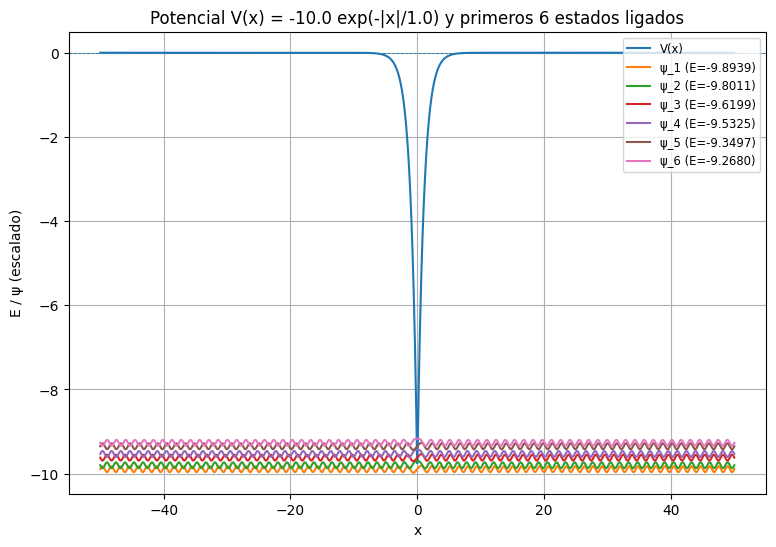


Resumen breve de las soluciones (E, puntos_en_malla, x_min, x_max):
(np.float64(-9.89393728252), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.801111545512), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.619865403066), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.532466270656), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.349712911993), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.267987867199), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.083474060971), 5999, np.float64(-50.0), np.float64(50.0))
(np.float64(-9.007637208242), 5999, np.float64(-50.0), np.float64(50.0))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def V_exp(x, V0, a):
    """Potencial simétrico de exponencial negativa: -V0 * exp(-|x|/a)."""
    return -V0 * np.exp(-np.abs(x) / a)

def f_of_x(x, E, V0, a, m=1.0, hbar=1.0):
    """Función f(x) en la forma psi'' = f(x) psi, donde
       f(x) = (2m/ħ^2) * (V(x) - E)."""
    return (2.0 * m / hbar**2) * (V_exp(x, V0, a) - E)

def numerov_outward(E, parity, x_max, N, V0, a, m=1.0, hbar=1.0):
    """
    Integra numéricamente desde x=0 hacia x=x_max usando el método de Numerov
    asumiendo la paridad (even/odd) para condiciones iniciales en x=0.
    Retorna x (>=0) y psi en esa malla (no normalizada).
    """
    x = np.linspace(0.0, x_max, N)
    h = x[1] - x[0]
    f = f_of_x(x, E, V0, a, m, hbar)
    psi = np.zeros_like(x)

    # condiciones iniciales en x=0 según la paridad (escala arbitraria)
    if parity == 'even':
        psi[0] = 1.0                       # psi(0) = 1 (escala arbitraria)
        psi[1] = psi[0] * (1.0 + 0.5 * h**2 * f[0])  # Taylor: psi(h)=psi0 + h^2/2 psi''(0)
    elif parity == 'odd':
        psi[0] = 0.0                       # psi(0) = 0 para estado impar
        psi[1] = h                         # psi'(0) = 1 (escala arbitraria) => psi(h) ~ h
    else:
        raise ValueError("parity must be 'even' or 'odd'")

    # Numerov recursion:
    # (1 + h^2/12 f_{n+1}) psi_{n+1} = 2(1 - 5h^2/12 f_n) psi_n - (1 + h^2/12 f_{n-1}) psi_{n-1}
    h2 = h * h
    coef = h2 / 12.0
    for n in range(1, N - 1):
        denom = 1.0 + coef * f[n + 1]
        term1 = 2.0 * (1.0 - 5.0 * coef * f[n]) * psi[n]
        term2 = (1.0 + coef * f[n - 1]) * psi[n - 1]
        psi[n + 1] = (term1 - term2) / denom

    return x, psi

def shoot_value(E, parity, x_max, N, V0, a, m=1.0, hbar=1.0):
    """Función para el método de 'shooting': devuelve psi(x_max) (valor en la frontera)
       para la energía E y la paridad dada. Usada para detectar cambios de signo (raíces)."""
    x, psi = numerov_outward(E, parity, x_max, N, V0, a, m, hbar)
    return psi[-1]

def find_bound_states(parity, V0, a, x_max=50.0, N=3000, m=1.0, hbar=1.0,
                      E_min=None, E_max=0.0, n_scan=400, tol=1e-8, max_bisect=60):
    """
    Busca energías ligadas (E<0) para la paridad dada:
      - Escanea E en [E_min, E_max] (si E_min es None se usa -V0*(1-1e-6))
      - Busca cambios de signo en psi(x_max) y aplica bisección para refinar la energía
    Retorna lista de (E, x_positive, psi_positive_normalized).
    """
    if E_min is None:
        E_min = -V0 * (1.0 - 1e-6)  # ligeramente por encima del mínimo del potencial

    E_grid = np.linspace(E_min, E_max, n_scan)
    F = []
    for E in E_grid:
        val = shoot_value(E, parity, x_max, N, V0, a, m, hbar)
        F.append(val)

    # buscar intervalos donde F cambia de signo
    roots = []
    for i in range(len(E_grid) - 1):
        if np.isnan(F[i]) or np.isnan(F[i+1]):
            continue
        if F[i] == 0.0:
            roots.append((E_grid[i], E_grid[i]))
        elif F[i] * F[i+1] < 0.0:
            # bracket encontrado, aplicar bisección
            E_lo, E_hi = E_grid[i], E_grid[i+1]
            F_lo, F_hi = F[i], F[i+1]
            it = 0
            while (E_hi - E_lo) > tol and it < max_bisect:
                E_mid = 0.5 * (E_lo + E_hi)
                F_mid = shoot_value(E_mid, parity, x_max, N, V0, a, m, hbar)
                if np.isnan(F_mid):
                    # si Numerov falló, ajustamos ligeramente
                    E_mid = 0.5 * (E_mid + E_lo)
                    F_mid = shoot_value(E_mid, parity, x_max, N, V0, a, m, hbar)
                if F_lo * F_mid <= 0.0:
                    E_hi = E_mid
                    F_hi = F_mid
                else:
                    E_lo = E_mid
                    F_lo = F_mid
                it += 1
            E_root = 0.5 * (E_lo + E_hi)
            roots.append((E_root, 0.0))
    # eliminar duplicados (por redondeo) y ordenar
    Es = sorted(set(np.round([r[0] for r in roots], 12)))
    solutions = []
    for E in Es:
        # obtener la psi positiva y normalizarla
        x_pos, psi_pos = numerov_outward(E, parity, x_max, N, V0, a, m, hbar)
        # reconstruir psi en dominio completo (-x_max, x_max)
        x_neg = -x_pos[1:][::-1]  # excluye el 0 para no duplicarlo
        x_full = np.concatenate([x_neg, x_pos])
        if parity == 'even':
            psi_neg = psi_pos[1:][::-1]
        else:
            psi_neg = -psi_pos[1:][::-1]
        psi_full = np.concatenate([psi_neg, psi_pos])

        # normalizar
        norm = np.sqrt(np.trapz(np.abs(psi_full)**2, x_full))
        psi_full /= norm

        solutions.append((E, x_full, psi_full))

    return solutions

# --- Parámetros de ejemplo ---
V0 = 10.0    # profundidad positiva; el potencial es -V0 en x=0
a = 1.0      # longitud de decaimiento
x_max = 50.0
N = 3000
m = 1.0
hbar = 1.0

print("Buscando estados ligados (paridad even)...")
even_solutions = find_bound_states('even', V0, a, x_max=x_max, N=N, m=m, hbar=hbar, n_scan=400)
print(f"Encontrados {len(even_solutions)} estados pares.")

print("Buscando estados ligados (paridad odd)...")
odd_solutions = find_bound_states('odd', V0, a, x_max=x_max, N=N, m=m, hbar=hbar, n_scan=400)
print(f"Encontrados {len(odd_solutions)} estados impares.")

all_solutions = sorted(even_solutions + odd_solutions, key=lambda s: s[0])

# Mostrar energías encontradas
print("\nEnergías ligadas encontradas (en las mismas unidades que V0):")
for i, (E, x_full, psi_full) in enumerate(all_solutions):
    parity = 'even' if i < len(even_solutions) else 'odd'
    print(f"  Estado {i+1:2d}: E = {E:.8f} (paridad: {'even' if (E in [s[0] for s in even_solutions]) else 'odd'})")

# Graficar potencial y los primeros 4 estados (si existen)
plt.figure(figsize=(9,6))
# crear malla para el potencial
x_plot = np.linspace(-x_max, x_max, 2000)
V_plot = V_exp(x_plot, V0, a)
plt.plot(x_plot, V_plot, label='V(x)')  # potencial

# ploteamos hasta 6 estados si existen (para no saturar la figura)
max_plot = min(6, len(all_solutions))
for idx in range(max_plot):
    E, x_full, psi_full = all_solutions[idx]
    # desplazamos la función de onda a la energía para visualizar (estado en su nivel E)
    psi_display = psi_full * 0.5 + E  # escala para ver la forma sin dominar la gráfica
    plt.plot(x_full, psi_display, label=f"ψ_{idx+1} (E={E:.4f})")

plt.axhline(0.0, linestyle='--', linewidth=0.6)
plt.xlabel("x")
plt.ylabel("E / ψ (escalado)")
plt.title(f"Potencial V(x) = -{V0} exp(-|x|/{a}) y primeros {max_plot} estados ligados")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.show()

# Opcional: devolver los primeros resultados en una forma legible
results = [(E, len(x_full), x_full[0], x_full[-1]) for (E, x_full, psi_full) in all_solutions[:8]]
print("\nResumen breve de las soluciones (E, puntos_en_malla, x_min, x_max):")
for r in results:
    print(r)